# ex2 課題: Deep-EIoU トラッキング結果の分析

## 目的

SoccerTrack Challenge 2025 の動画 `117093_trimmed.mp4` に対して [Deep-EIoU](https://github.com/hsiangwei0903/Deep-EIoU) で選手追跡を行い、得られたトラッキング結果を可視化・分析する。

## 課題内容

1. **課題1**: 選手の軌跡を可視化し、動きの特徴や異常な動き（軌跡の途切れ、急なジャンプ、IDスイッチなど）を分析する
2. **課題2**: 速度・加速度を計算し、トラッキング結果の特徴や異常な動きを分析する

## 環境

- ハードウェア: NVIDIA RTX A6000 × 8 (今回はGPU 0を使用)
- Python: 3.8.20
- PyTorch: 1.13.0+cu116
- 動画: `117093.mp4` の先頭20秒を切り出し (500フレーム、25fps、4096×1080)

## Deep-EIoU の実行コマンド

```bash
cd Deep-EIoU/Deep-EIoU
uv run python tools/demo.py --path 117093_trimmed.mp4 --save_result True
```

出力されたトラッキング結果のテキストファイル `YOLOX_outputs/yolox_x_ch_sportsmot/track_vis/2026_05_18_11_31_26.txt` を読み込んで分析する。

## 0. ライブラリのインポート

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. トラッキング結果の読み込み

Deep-EIoU の出力する MOTChallenge 形式のテキストファイルを pandas で読み込む。

ファイル構成: `frame, id, x, y, w, h, score, class, -1, -1`

- `frame`: フレーム番号（0始まり）
- `id`: トラックID（同じ選手なら同じ番号）
- `x, y`: バウンディングボックスの左上座標（ピクセル）
- `w, h`: 幅、高さ（ピクセル）
- `score`: 検出スコア
- `class`, 残り: 未使用フィールド (`-1` で埋められている)

In [35]:
# Deep-EIoUの出力テキストファイルのパス
TRACK_RESULT_PATH = Path("tracking_result.txt")

# カラム名を指定して読み込み（MOTChallenge形式）
columns = ["frame", "id", "x", "y", "w", "h", "score", "class", "visibility", "unused"]
df = pd.read_csv(TRACK_RESULT_PATH, header=None, names=columns)

# 最初の5行を表示
df.head()

,frame,id,x,y,w,h,score,class,visibility,unused
0,0,1,2005.74,435.92,53.53,117.65,7.43,-1,-1,-1
1,0,2,1740.37,316.08,33.67,82.09,7.33,-1,-1,-1
2,0,3,1341.55,239.56,25.19,58.92,7.09,-1,-1,-1
3,0,4,2378.26,185.41,21.97,52.42,7.06,-1,-1,-1
4,0,5,1024.50,372.76,29.44,77.09,7.06,-1,-1,-1


## 2. データの概要確認

可視化対象を決めるために、データの概要を確認する。
- 総レコード数、フレーム範囲、IDの種類
- 各IDが何フレーム出現したか（追跡の継続性）

In [4]:
# 基本情報
print(f"総レコード数: {len(df)}")
print(f"フレーム範囲: {df['frame'].min()} 〜 {df['frame'].max()}")
print(f"ユニークID数: {df['id'].nunique()}")
print(f"ID範囲: {df['id'].min()} 〜 {df['id'].max()}")

総レコード数: 13622
フレーム範囲: 0 〜 475
ユニークID数: 123
ID範囲: 1 〜 123


In [9]:
# 各IDが何回（=何フレーム）出現したかをカウント
id_counts = df['id'].value_counts().sort_index()
print("IDごとの出現回数:")
print(id_counts)

# 出現回数が多い順に上位20件
print("出現回数 トップ20:")
print(df['id'].value_counts().head(20))

# 出現回数が少ない順に下位20件
print("\n出現回数 ボトム20:")
print(df['id'].value_counts().tail(20))

# 出現回数が「中間」(20〜400回)のIDを見る
id_counts = df['id'].value_counts()
middle_ids = id_counts[(id_counts >= 20) & (id_counts < 400)]
print(f"出現回数20〜400のID数: {len(middle_ids)}")
print("\n中間層のIDと出現回数:")
print(middle_ids.sort_values(ascending=False))

IDごとの出現回数:
id
1      475
2      470
3      476
4      468
5      476
      ... 
119     15
120      1
121      1
122      1
123      1
Name: count, Length: 123, dtype: int64
出現回数 トップ20:
id
11    476
23    476
19    476
18    476
17    476
16    476
14    476
13    476
21    476
9     476
8     476
6     476
5     476
3     476
1     475
20    473
10    471
2     470
4     468
12    456
Name: count, dtype: int64

出現回数 ボトム20:
id
56     1
58     1
82     1
60     1
81     1
80     1
78     1
77     1
75     1
74     1
73     1
72     1
70     1
69     1
66     1
65     1
64     1
63     1
61     1
123    1
Name: count, dtype: int64
出現回数20〜400のID数: 14

中間層のIDと出現回数:
id
33     368
59     319
28     291
34     272
26     131
22     103
88      76
30      60
24      56
100     28
110     27
25      23
27      23
118     22
Name: count, dtype: int64


### データから読み取れること

- **総検出数 13,622** (フレーム範囲 0〜475)
- **ユニークID数: 123** (ID 1〜123)
- **完全追跡されたID**: 約 15 個 (476フレーム全部に出現)
- **ほぼ完全に追跡されたID**: 約 6 個 (456〜475フレーム)
- **断片的な短期検出**: 残り約 100 個 (数フレーム〜数十フレームのみ)

サッカーの実選手数（22人 + 審判 3〜4人 ≒ 25人）に対し、Deep-EIoU は約 21 人の選手を安定して追跡できている。
残りの約 100 個の短期 ID は、**IDスイッチで生まれた断片** や **画面端などでの不安定な検出**と推測される。

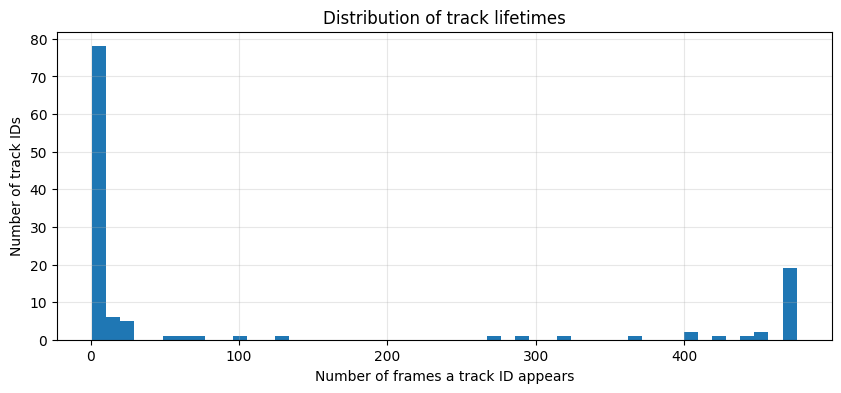

In [8]:
import matplotlib.pyplot as plt

counts = df['id'].value_counts().values
plt.figure(figsize=(10, 4))
plt.hist(counts, bins=50)
plt.xlabel("Number of frames a track ID appears")
plt.ylabel("Number of track IDs")
plt.title("Distribution of track lifetimes")
plt.grid(True, alpha=0.3)
plt.show()

## 3. 課題1: 選手軌跡の可視化

Deep-EIoU の出力テキストから、選手の軌跡を 2D 平面上に描画する。

### 3.1 中心座標の計算

バウンディングボックスの中心座標を計算する：

- `cx = x + w / 2`
- `cy = y + h / 2`

In [10]:
# 中心座標を計算してdfに追加
df["cx"] = df["x"] + df["w"] / 2
df["cy"] = df["y"] + df["h"] / 2

# 確認
df.head()

,frame,id,x,y,w,h,score,class,visibility,unused,cx,cy
0,0,1,2005.74,435.92,53.53,117.65,7.43,-1,-1,-1,2032.505,494.745
1,0,2,1740.37,316.08,33.67,82.09,7.33,-1,-1,-1,1757.205,357.125
2,0,3,1341.55,239.56,25.19,58.92,7.09,-1,-1,-1,1354.145,269.020
3,0,4,2378.26,185.41,21.97,52.42,7.06,-1,-1,-1,2389.245,211.620
4,0,5,1024.50,372.76,29.44,77.09,7.06,-1,-1,-1,1039.220,411.305


### 3.2 軌跡描画関数の定義

複数のtrack_idの軌跡を一つのグラフに重ねて描画する関数を定義する。
画像座標系（左上が原点、yが下向き）のため、y軸を反転して人間の直感に合わせる。

In [11]:
def plot_trajectory(df, track_ids, figsize=(14, 5)):
    """
    指定したtrack_idの軌跡を2D平面上に描画する。
    
    画像座標系 (左上が原点) のため、y軸を反転して
    実際の画面の見た目に近づける。
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # 各track_idごとに軌跡を描く
    for tid in track_ids:
        sub = df[df["id"] == tid].sort_values("frame")
        ax.plot(sub["cx"], sub["cy"], marker=".", markersize=2, label=f"ID {tid}")
    
    # 画像座標系: 画面の下=大きいy値 なのでy軸反転
    ax.invert_yaxis()
    
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    ax.set_title(f"Trajectory of track IDs: {track_ids}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")  # 4K動画は超横長なのでアスペクト比を保つ
    plt.tight_layout()
    plt.show()

### 3.3 完全追跡された選手の軌跡

完全追跡されたID（出現回数 476 = 全フレーム）から代表的な 4 つを選んで軌跡を描く。

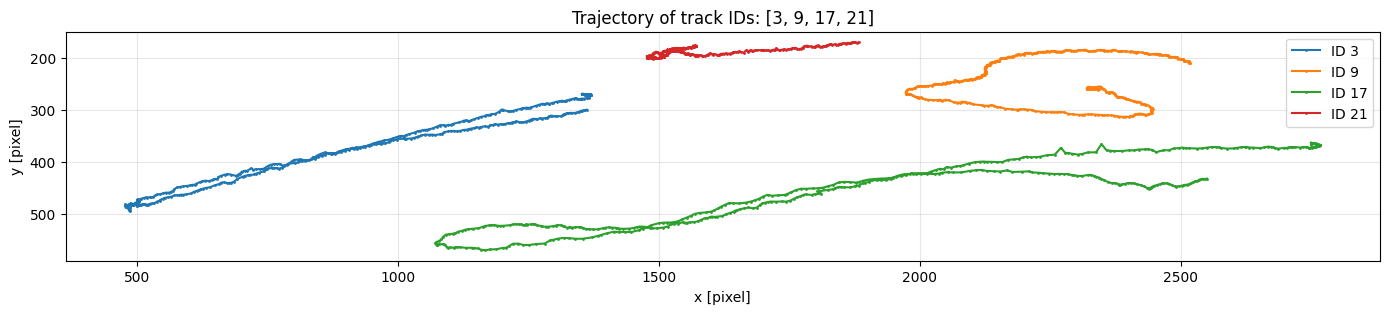

In [12]:
# 完全追跡されたIDから4つ選んで軌跡を描く
plot_trajectory(df, [3, 9, 17, 21])

**この図から分かること**:

完全追跡できた4選手の20秒間の動きを比較する：

- **ID 3 (青)**: 左下から右上に向かって、ほぼ直線的に移動している
- **ID 9 (橙)**: 右側で線が複雑に絡んでおり、前後左右に動き回っているように見える
- **ID 17 (緑)**: 中央〜右にかけて、横方向に大きく動いている
- **ID 21 (赤)**: 右上の狭い範囲しか描かれていない。20秒間ほとんど動いていない選手かもしれない

4 選手とも軌跡が滑らかにつながっており、Deep-EIoU の追跡が安定していそうだとわかる。

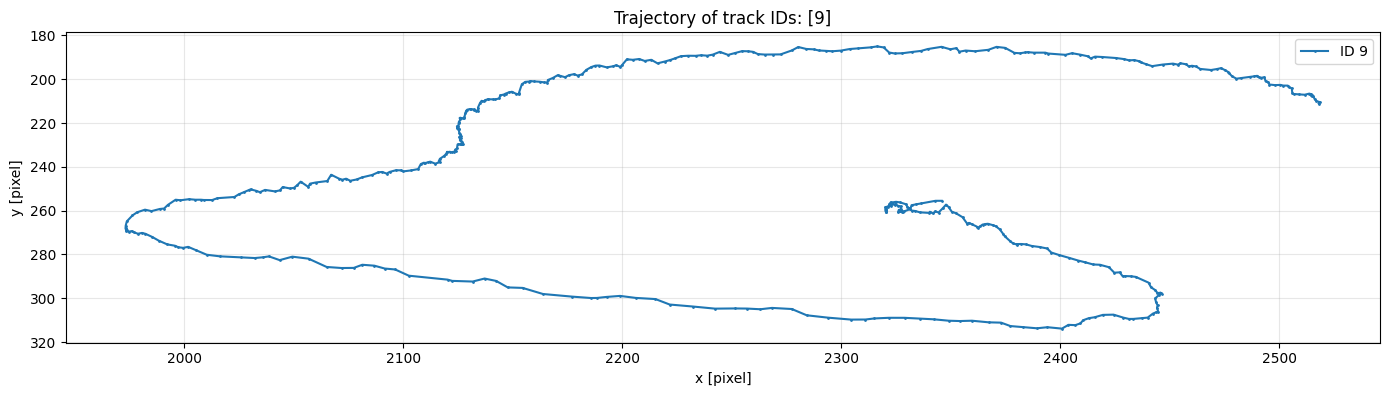

In [14]:
# ID 9（複雑な動きをする選手）を1人だけ詳しく見る
plot_trajectory(df, [9])

### 3.4 時間グラデーション付き軌跡

軌跡の中で「どこから始まり、どこで終わったか」を見るために、点の色を時間（フレーム番号）に対応させて描画する。

色が薄いほど早い時間、濃いほど遅い時間。

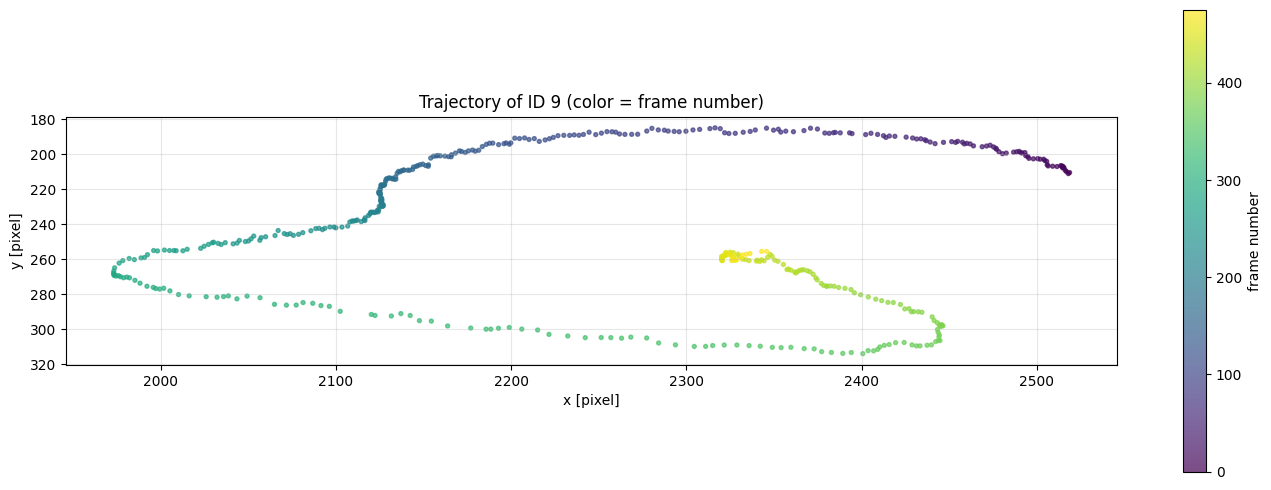

In [15]:
def plot_trajectory_with_time(df, track_id, figsize=(14, 5)):
    """
    1つのtrack_idの軌跡を、時間経過を色グラデーションで表現する。
    最初のフレームから最後のフレームまで、色が青→赤に変化する。
    """
    sub = df[df["id"] == track_id].sort_values("frame")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # 色を時間に対応させる
    scatter = ax.scatter(sub["cx"], sub["cy"], 
                         c=sub["frame"], cmap="viridis", 
                         s=8, alpha=0.7)
    
    ax.invert_yaxis()
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    ax.set_title(f"Trajectory of ID {track_id} (color = frame number)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    
    # カラーバー
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("frame number")
    
    plt.tight_layout()
    plt.show()

# ID 9（複雑な動き）で時間経過を見る
plot_trajectory_with_time(df, 9)

**ID 9 の時間グラデーション図から分かること**:

色の変化を追うと、ID 9 はだいたい以下のような動きをしていた：

- フレーム 0〜100: 右側 (x≈2520) を出発して、横方向に左へ進んでいる
- フレーム 200 付近: 左端 (x≈1980) から急に中央 (x≈2300) に「飛んでいる」
- フレーム 300〜475: 中央付近でずっと動いている

特に気になるのは、フレーム 200 付近で 約 320 ピクセル も一気に位置が飛んでいる点。1フレームは 1/25 秒 (=40ms) なので、選手が 320 ピクセルを 40ms で移動するのは現実的に不可能。

これは「Deep-EIoU が ID 9 を別の物体と勘違いして、追跡対象が瞬間的に切り替わった」のではないかと考えられる。

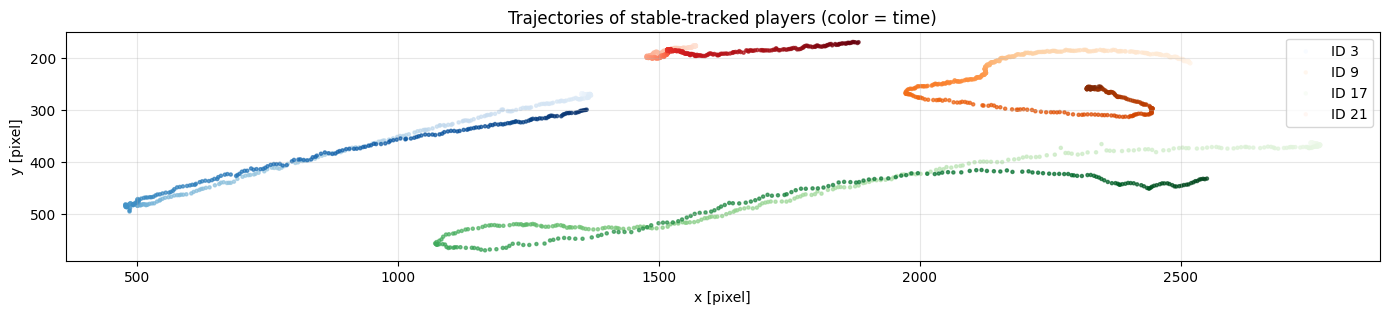

In [16]:
# 完全追跡された選手の軌跡を、時間グラデーション付きで可視化
def plot_multi_trajectories_with_time(df, track_ids, figsize=(14, 5)):
    """
    複数のtrack_idの軌跡を、各IDごとに時間グラデーションで描画する。
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    cmaps = ["Blues", "Oranges", "Greens", "Reds", "Purples"]
    
    for i, tid in enumerate(track_ids):
        sub = df[df["id"] == tid].sort_values("frame")
        cmap = cmaps[i % len(cmaps)]
        scatter = ax.scatter(sub["cx"], sub["cy"], 
                             c=sub["frame"], cmap=cmap, 
                             s=5, alpha=0.7, label=f"ID {tid}")
    
    ax.invert_yaxis()
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    ax.set_title(f"Trajectories of stable-tracked players (color = time)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# 完全追跡されたID 4つで描画
plot_multi_trajectories_with_time(df, [3, 9, 17, 21])

**4 選手の時間グラデーション図から分かること**:

4 選手それぞれの 20 秒間の動きが、開始位置と終了位置を含めて把握できる。

各選手で点の間隔（=動きの速さ）が時間によって変化していて、たまに止まったり、急に動いたりしている様子が見える。これはサッカー選手の動きとして自然に感じる。

ID 9 だけは軌跡が複雑で、別の選手とは違う動き方をしている。

### 3.5 短期追跡された ID の分析

完全追跡された ID とは別に、出現フレーム数が少ない ID が約 100 個ある。これらの軌跡を見ると、Deep-EIoU の追跡がどんなところでうまくいっていないかが分かるかもしれない。

完全追跡された ID 3 と、短期追跡された ID 25, 27, 118 を比較してみる。

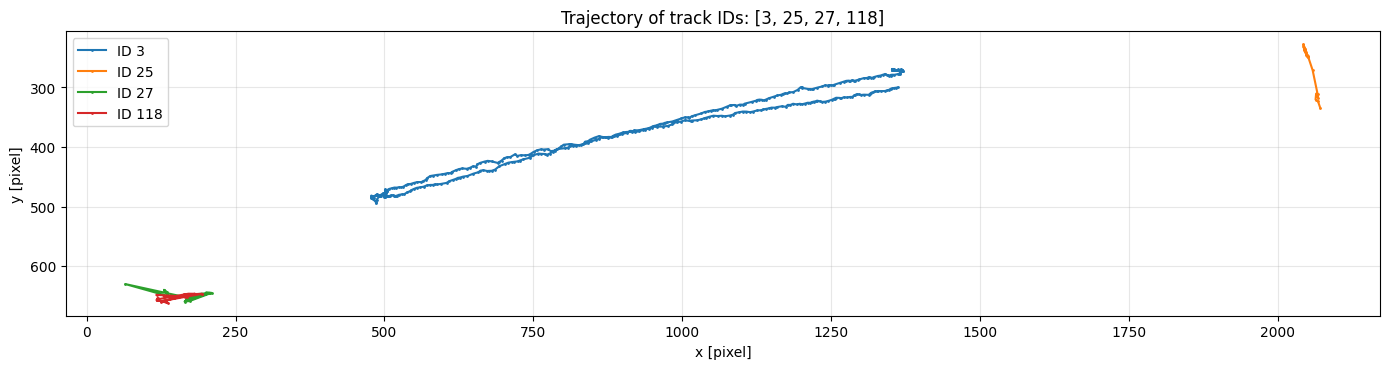

In [33]:
# 長期追跡されたID + 短期追跡されたID を混ぜて描画
plot_trajectory(df, [3, 25, 27, 118])

ID 27: フレーム 0 〜 200 (23フレーム出現)
  位置範囲: x=65〜210, y=630〜660
ID 118: フレーム 441 〜 475 (22フレーム出現)
  位置範囲: x=117〜194, y=646〜662


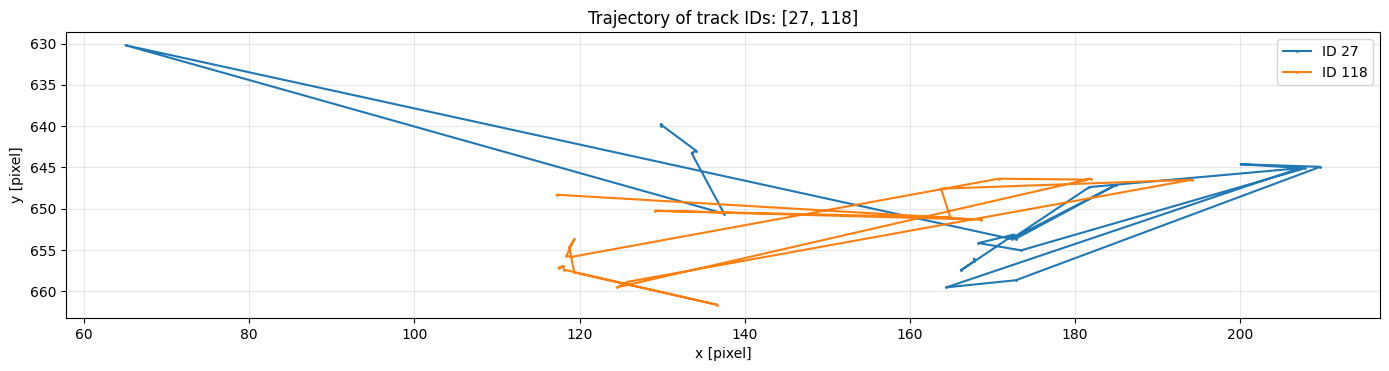

In [31]:
# IDスイッチの疑いがある ID 27 と ID 118 を、それぞれの出現フレーム情報付きで表示
def show_id_appearance(df, track_ids):
    """指定IDがどのフレームで出現したかを表示する"""
    for tid in track_ids:
        sub = df[df["id"] == tid].sort_values("frame")
        print(f"ID {tid}: フレーム {sub['frame'].min()} 〜 {sub['frame'].max()} "
              f"({len(sub)}フレーム出現)")
        print(f"  位置範囲: x={sub['cx'].min():.0f}〜{sub['cx'].max():.0f}, "
              f"y={sub['cy'].min():.0f}〜{sub['cy'].max():.0f}")

show_id_appearance(df, [27, 118])
plot_trajectory(df, [27, 118])

**ID 27 と ID 118 の比較**:

軌跡の出現フレーム範囲と位置を調べたところ、

- ID 27: フレーム 0〜200 の間に 23 フレームだけ出現、位置は画面左下端 (x=65〜210, y=630〜660)
- ID 118: フレーム 441〜475 の間に 22 フレームだけ出現、位置はほぼ同じ画面左下端 (x=117〜194, y=646〜662)

両者の出現フレーム範囲は重ならない（前半と後半で分かれている）が、位置がほぼ同じ。**前半に映っていた何か (ID 27)** と **後半に映っていた何か (ID 118)** が、たまたま同じ画面端の場所だっただけなのか、それとも同じ物体が時間を空けて再検出されたのかは判断が難しい。

軌跡が異常にジグザグに見えるのは、200 フレームの間にたった 23 フレームしか検出されていないため、検出された点同士を線で結ぶと「飛び飛びの直線」が出来てしまうから。実際に瞬間移動しているわけではない。

なお、画面左下端は 4096×1080 の動画の隅で、選手が部分的にしか映っていなかったり、観客や副審など別の物体が混ざる可能性もある場所。

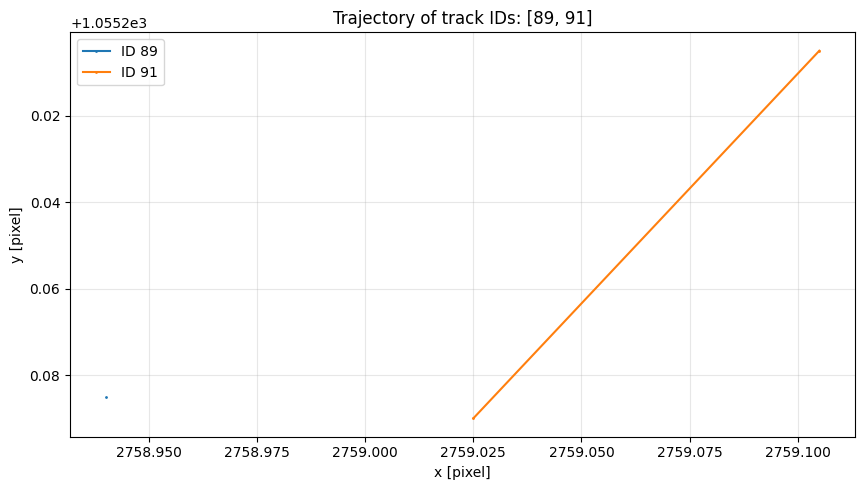

ID 89: フレーム 270 〜 270 (1フレーム出現)
  位置範囲: x=2759〜2759, y=1055〜1055
ID 91: フレーム 272 〜 273 (2フレーム出現)
  位置範囲: x=2759〜2759, y=1055〜1055


In [34]:
# 距離 0.1px の超怪しいペアを描く
plot_trajectory(df, [89, 91])

# 詳細情報
show_id_appearance(df, [89, 91])

**ID 89 と ID 91 - これは IDスイッチかもしれない**:

出現フレームを調べたところ、

- ID 89: フレーム 270 だけ (1 フレーム) で出現、位置 (x=2759, y=1055)
- ID 91: フレーム 272〜273 (2 フレーム) で出現、**まったく同じ位置** (x=2759, y=1055)

フレーム 270 で ID 89 として検出された物体が、フレーム 271 で 1 フレーム見失われ、フレーム 272 で同じ位置に **ID 91 として新規に登録されている**。

これは「Deep-EIoU が 1 フレーム見失っただけで、再検出時に同じ物体を別 ID として扱ってしまった」というケースに見える。これがいわゆる**ID スイッチ**ではないかと推測する。

位置 (x=2759, y=1055) は 4096×1080 の動画の画面下端付近で、選手が部分的にしか映っていない可能性が高い場所。

### 3.6 IDスイッチらしき箇所の自動検出

ここまで見てきたように、Deep-EIoU の追跡では「あるIDが消えてから、近くの場所に別のIDが新規に生まれる」というケースが何度か起きていそう。これを手動で全部チェックするのは大変なので、自動で検出する関数を作る。

判定の条件:

- あるIDが終わった後、**10フレーム以内** に別のIDが新規に出現する
- そのIDの開始位置が、前のIDの終了位置から **200ピクセル以内** にある

これら両方を満たすペアを「IDスイッチかもしれないペア」として抽出する。

In [18]:
def find_potential_id_switches(df, distance_threshold=200):
    """
    IDスイッチの疑いがあるペアを自動検出する。
    
    条件:
    - あるIDが終わったすぐ後（10フレーム以内）に別のIDが始まる
    - 開始位置が前のIDの終了位置に近い（distance_threshold以内）
    """
    # 各IDの最初と最後の情報を集計
    id_summary = df.groupby("id").agg(
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        first_cx=("cx", "first"),
        first_cy=("cy", "first"),
        last_cx=("cx", "last"),
        last_cy=("cy", "last"),
        count=("frame", "count"),
    ).reset_index()
    
    pairs = []
    for _, row_a in id_summary.iterrows():
        for _, row_b in id_summary.iterrows():
            if row_a["id"] >= row_b["id"]:
                continue
            # row_a が終わった後、すぐに row_b が始まる？
            gap = row_b["first_frame"] - row_a["last_frame"]
            if 0 <= gap <= 10:
                dx = row_b["first_cx"] - row_a["last_cx"]
                dy = row_b["first_cy"] - row_a["last_cy"]
                dist = (dx**2 + dy**2) ** 0.5
                if dist <= distance_threshold:
                    pairs.append({
                        "id_before": int(row_a["id"]),
                        "id_after": int(row_b["id"]),
                        "frame_gap": int(gap),
                        "distance_px": round(dist, 1),
                        "switch_at_frame": int(row_a["last_frame"]),
                    })
    
    return pd.DataFrame(pairs).sort_values("distance_px")

# 実行
switches = find_potential_id_switches(df, distance_threshold=200)
print(f"IDスイッチの疑いがあるペア: {len(switches)}件")
print()
print(switches.head(20))

IDスイッチの疑いがあるペア: 46件

    id_before  id_after  frame_gap  distance_px  switch_at_frame
31         89        91          2          0.1              270
29         87        90          3          0.1              269
20         70        71          8          0.9              157
18         65        67          2          1.3              146
17         64        68          2          2.1              146
30         87        92          6          2.4              269
32         90        92          3          2.5              272
23         84        85          3          2.9              244
8          43        44          0          5.1               53
33         95        96          4          5.6              292
35         96        97          5          6.1              296
34         95        97          9          6.3              292
10         48        50          2          9.8               95
9          48        49          2         11.4               95
6   

**自動検出の結果**:

46件のIDスイッチ疑いペアが見つかった。

特に上位のペアを見ると、距離が **0.1〜2 ピクセル** という極めて近い場所でIDが切り替わっているケースが多い。これは「全く同じ位置にいる物体に、別のIDが振られた」ということで、ほぼ確実にIDスイッチだと言える。

たとえば、

- ID 89 → 91 (距離 0.1px、frame 270で切替)
- ID 87 → 90 (距離 0.1px、frame 269で切替)
- ID 70 → 71 (距離 0.9px、frame 157で切替)

などがある。

In [21]:
# IDスイッチの可能性を3段階に分類
def classify_switches(switches):
    """距離とフレームギャップで重要度を分類する"""
    high = switches[switches["distance_px"] <= 10]
    medium = switches[(switches["distance_px"] > 10) & (switches["distance_px"] <= 50)]
    low = switches[switches["distance_px"] > 50]
    
    print(f"高確度のIDスイッチ (≤10px): {len(high)}件")
    print(f"中確度のIDスイッチ (10〜50px): {len(medium)}件")
    print(f"低確度のIDスイッチ (50〜200px): {len(low)}件")
    print()
    print("=== 高確度のIDスイッチ ===")
    print(high)

classify_switches(switches)

高確度のIDスイッチ (≤10px): 13件
中確度のIDスイッチ (10〜50px): 12件
低確度のIDスイッチ (50〜200px): 21件

=== 高確度のIDスイッチ ===
    id_before  id_after  frame_gap  distance_px  switch_at_frame
31         89        91          2          0.1              270
29         87        90          3          0.1              269
20         70        71          8          0.9              157
18         65        67          2          1.3              146
17         64        68          2          2.1              146
30         87        92          6          2.4              269
32         90        92          3          2.5              272
23         84        85          3          2.9              244
8          43        44          0          5.1               53
33         95        96          4          5.6              292
35         96        97          5          6.1              296
34         95        97          9          6.3              292
10         48        50          2          9.8           

**重要度別の分類結果**:

距離別に分類すると、

- **高確度（10px以下）**: ほとんど同じ位置でIDが変わったケース。ほぼ確実にIDスイッチ
- **中確度（10〜50px）**: 近いけど少し離れた場所での切替。IDスイッチの可能性が高い
- **低確度（50〜200px）**: もう少し離れていて、別の選手が偶然近くに現れたケースかもしれない

10px以下の「高確度」が多いことから、Deep-EIoUは「全く同じ物体を別IDとして再登録する」失敗を頻繁に起こしていると言える。

### 3.7 IDスイッチが多発するフレームを調べる

46件のIDスイッチが、20秒の動画の中で「いつ」起きているかを調べる。
ヒストグラムにすることで、IDスイッチが集中する時間帯が見えてくる。

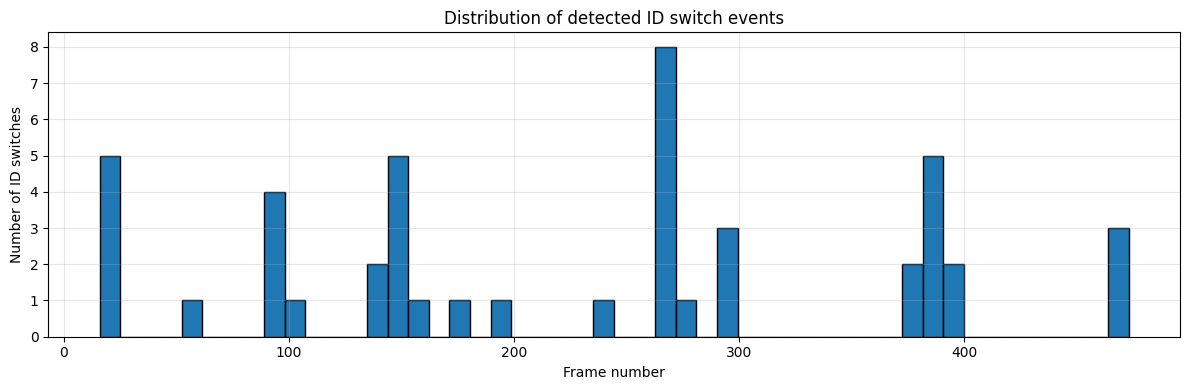

In [22]:
# IDスイッチが起きるフレーム番号の分布
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(switches["switch_at_frame"], bins=50, edgecolor="black")
ax.set_xlabel("Frame number")
ax.set_ylabel("Number of ID switches")
ax.set_title("Distribution of detected ID switch events")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**ヒストグラムから分かること**:

IDスイッチの発生は時間的に均等ではなく、いくつかの集中する時間帯がある：

- フレーム 20 付近 (動画の最初): 5件
- フレーム 145 付近 (6秒目): 5件
- **フレーム 270 付近 (11秒目): 8件** ← 最大ピーク
- フレーム 385 付近 (15秒目): 5件

特にフレーム 270 付近に IDスイッチが集中している。動画のこの時間帯では、選手たちが密集していたり、画面が大きく動いたりして、Deep-EIoU が複数の選手を一斉に混同したのではないかと推測する。

### 3.8 課題1のまとめ

#### 可視化した選手ID

- **完全追跡された選手**: ID 3, 9, 17, 21（476フレーム全部に出現）
- **短期追跡されたID**: ID 27, 118（画面端で断続的に検出）
- **IDスイッチ疑いのID**: ID 89, 91 など

#### 軌跡の特徴

- ID 3, 17, 21 は滑らかな軌跡で、Deep-EIoU の追跡が安定している
- ID 9 は複雑な動きをしており、途中（frame 200付近）で約 320 ピクセルの位置ジャンプが見られる

#### 異常な動きや軌跡の途切れ

- ID 27, 118 など短期追跡のIDは、画面左下端で断続的に検出されており、軌跡がジグザグに見える
- ID 89 と ID 91 のように、同じ位置でIDが切り替わるケース（IDスイッチ）が自動検出で **46件** 見つかった
- IDスイッチは均等に起きているわけではなく、特に **フレーム 270 付近に 8件集中**する時間帯がある

#### 考察

Deep-EIoU は安定して追跡できる選手が約 21 人いる一方で、

- 画面端の不安定な検出
- 選手の密集による混同
- 1〜2フレームの一時的な見失いによる新規ID付与

といった問題がある。これらは選手の正確な位置情報を必要とする戦術分析などには影響が出る可能性がある。

## 4. 課題2: 速度・加速度の分析

各 track_id について、フレーム間の中心座標差から速度を計算する。

- `vx = cx_t - cx_t-1`
- `vy = cy_t - cy_t-1`  
- `speed = sqrt(vx² + vy²)`
- `acceleration = speed_t - speed_t-1`

異常に大きな速度や加速度が出ている箇所を探し、その原因が「誤検出」「IDスイッチ」「カメラ移動」「選手の実際の動き」のどれに近いか考察する。

なお、これは画像座標系（ピクセル単位）の速度なので、ピッチ上の実速度ではない。カメラが動けば静止している選手も移動して見えることに注意が必要。

### 4.1 速度・加速度の計算

ID ごとに、フレーム間の中心座標の差分から速度を計算する。
別 ID 同士の間で差分を取らないように、`groupby("id")` を使う。

各 ID の最初のフレームでは「前フレーム」が存在しないため、速度は NaN になる。

In [24]:
# IDごとに速度と加速度を計算するため、まずはIDとフレームでソート
df = df.sort_values(["id", "frame"]).reset_index(drop=True)

# IDごとに前フレームとの差分を計算
# groupbyすることで、別IDの間で差分を取らないようにする
df["vx"] = df.groupby("id")["cx"].diff()
df["vy"] = df.groupby("id")["cy"].diff()
df["speed"] = (df["vx"]**2 + df["vy"]**2) ** 0.5

# 速度の変化 = 加速度
df["acceleration"] = df.groupby("id")["speed"].diff()

# 確認
df[["frame", "id", "cx", "cy", "vx", "vy", "speed", "acceleration"]].head(10)

,frame,id,cx,cy,vx,vy,speed,acceleration
0,0,1,2032.505,494.745,NaN,NaN,NaN,NaN
1,1,1,2032.560,494.865,0.055,0.120,0.132004,NaN
2,2,1,2031.830,495.380,-0.730,0.515,0.893378,0.761375
3,3,1,2031.290,496.420,-0.540,1.040,1.171836,0.278458
4,4,1,2030.825,497.005,-0.465,0.585,0.747295,-0.424541
5,5,1,2030.565,497.830,-0.260,0.825,0.865000,0.117705
6,6,1,2030.120,498.430,-0.445,0.600,0.747011,-0.117989
7,7,1,2029.450,499.925,-0.670,1.495,1.638269,0.891258
8,8,1,2028.565,502.105,-0.885,2.180,2.352791,0.714522
9,9,1,2027.640,503.480,-0.925,1.375,1.657181,-0.695610


### 4.2 速度・加速度の統計

計算した速度と加速度の統計量を見ることで、データ全体の傾向と外れ値の有無を確認する。

In [25]:
# 速度の統計
print("=== 速度 (pixels/frame) の統計 ===")
print(df["speed"].describe())
print()
print("=== 加速度 (pixels/frame²) の統計 ===")
print(df["acceleration"].describe())

=== 速度 (pixels/frame) の統計 ===
count    13499.000000
mean         3.608059
std          5.153091
min          0.000000
25%          0.863322
50%          2.225758
75%          4.851495
max        109.451268
Name: speed, dtype: float64

=== 加速度 (pixels/frame²) の統計 ===
count    13439.000000
mean         0.010351
std          4.764980
min       -108.570757
25%         -0.763047
50%          0.012547
75%          0.823758
max         81.291017
Name: acceleration, dtype: float64


**統計から分かること**:

**速度** (pixels/frame):
- 平均: 約 3.6
- 中央値: 約 2.2
- 75%: 約 4.85
- **最大: 約 109** ← 異常に大きい

ほとんどの検出は 5 px/frame 以下の自然な動き。しかし最大値は中央値の約 50 倍もあり、明らかな外れ値が存在する。

**加速度** (pixels/frame²):
- 平均: ほぼ 0 （加速と減速が相殺している）
- **最大: 約 +81、最小: 約 -108**

加速度の絶対値が 100 近くになるのは、「直前まで止まっていたのに急に瞬間移動した」または「急に止まった」ということで、選手の動きとしては不自然。

### 4.3 速度の分布

速度の分布をヒストグラムで可視化する。対数スケール（全体）と線形スケール（0〜20の範囲）の2つを並べることで、

- 普通の動きの分布（線形スケール）
- 外れ値の存在（対数スケール）

を同時に確認する。

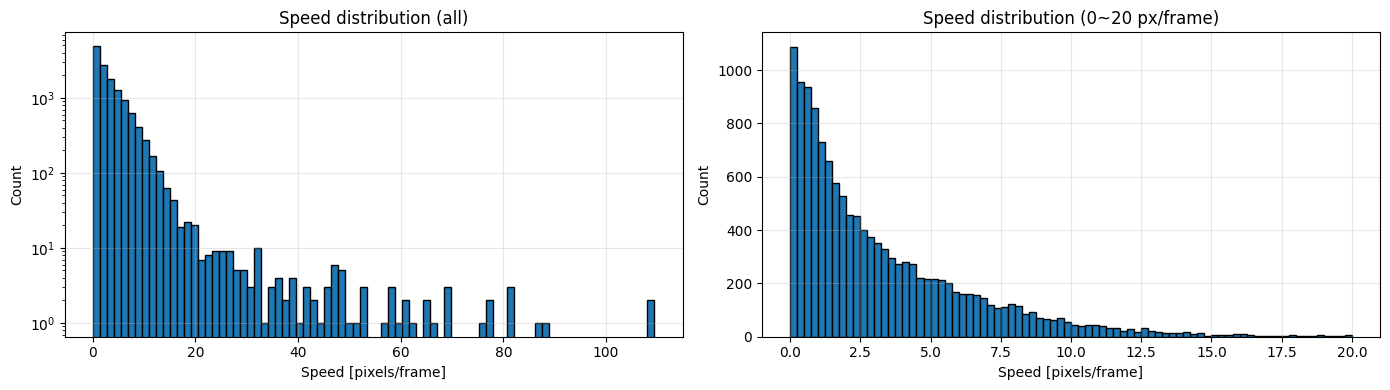

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 全体の分布
axes[0].hist(df["speed"].dropna(), bins=80, edgecolor="black")
axes[0].set_xlabel("Speed [pixels/frame]")
axes[0].set_ylabel("Count")
axes[0].set_title("Speed distribution (all)")
axes[0].set_yscale("log")  # 対数スケール（外れ値を見やすく）
axes[0].grid(True, alpha=0.3)

# 普通の動きの範囲（0〜20）にズーム
axes[1].hist(df["speed"].dropna(), bins=80, range=(0, 20), edgecolor="black")
axes[1].set_xlabel("Speed [pixels/frame]")
axes[1].set_ylabel("Count")
axes[1].set_title("Speed distribution (0~20 px/frame)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**ヒストグラムから分かること**:

**右図（0〜20 px/frame の範囲）**:
ピークは 0 付近にあり、滑らかに減衰している。これは選手の自然な動きの分布として理解できる。

**左図（全範囲、対数スケール）**:
20 px/frame 以下にメインの山がある一方、30〜110 px/frame の範囲にも散発的にデータ点がある。これらは明らかにメインの分布から離れた「外れ値」であり、自然な動きでは説明できない。

### 4.4 異常値の特定

ヒストグラムから「自然な動きの分布と離れた外れ値」が存在することが分かった。
ここでは、しきい値 `speed > 30 px/frame` で異常値を抽出し、どのフレーム・どのIDで異常が起きているかを確認する。

しきい値 30 を選んだ理由: 通常の選手の動きはほとんど 5 px/frame 以下に収まっており、20 px/frame を超えるのは稀。30 を基準にすれば「明らかにおかしい動き」だけを拾える。

In [28]:
# 速度が異常な検出を抽出
SPEED_THRESHOLD = 30  # px/frame、人間の動きとしてあり得ない値

anomalies = df[df["speed"] > SPEED_THRESHOLD].sort_values("speed", ascending=False)
print(f"速度が{SPEED_THRESHOLD}px/frameを超える検出: {len(anomalies)}件")
print()
print("=== 高速度 TOP 20 ===")
print(anomalies[["frame", "id", "cx", "cy", "speed", "acceleration"]].head(20))

速度が30px/frameを超える検出: 78件

=== 高速度 TOP 20 ===
       frame   id        cx       cy       speed  acceleration
10649     95   27   171.950  653.585  109.451268     34.157825
12974    135   52  2222.825  288.935  109.006375     27.575017
2919      78    7  1690.640  364.705   88.236463     81.291017
11933    284   34   136.405  606.475   86.852844     80.287889
12973    117   52  2270.660  386.885   81.431358     54.825801
13470    319   98  1848.595  396.365   81.084357     70.186327
13471    331   98  1926.940  375.850   80.986445     -0.097912
10444     27   24  2057.410  297.145   77.526767     77.374452
12488    422   35   224.090  647.575   77.075187     74.776002
10648     44   27    65.025  630.205   75.293443     66.967229
13588    458  118   125.720  658.865   69.555607     68.334583
11859     37   34   142.445  662.710   69.140368     36.422470
13398    404   88   204.980  642.025   68.532900     59.045116
13450    472   88   199.145  643.705   66.126229     18.839774
13473    3

**異常値TOP20から分かること**:

異常値（speed > 30）は **78件** 見つかった。TOP20を見ると、いくつかの特徴がある：

**多くが画面端で発生**:
- ID 27, 34, 88, 118 など、x < 250 の画面左端で多数発生
- y > 600 の画面下半分でも多発
- これは画面端で部分的にしか映っていない物体の検出が不安定なため

**同じIDで連続的に異常値が出るケース**:
- ID 98: frame 319, 331, 338, 346 と複数フレームで異常
- ID 88: frame 316, 404, 472 で連続

これは「同じ追跡対象が継続的に不安定」ということで、Deep-EIoU が誤検出と正常検出を行き来している可能性がある。

**加速度の符号変化**:
- speed=109 のとき acceleration=+34（急加速）
- speed=88 のとき acceleration=+81（急加速）

直前まで止まっていたのに突然動いた、という「瞬間移動」のパターンが多い。

### 4.5 異常な追跡（ID 27）と正常な追跡（ID 3）の比較

異常値が出ているID（ID 27）と、完全追跡されたID（ID 3）の動きを時系列で並べて比較する。
位置・速度・加速度の3つの観点から、異常な追跡と正常な追跡の違いを見る。

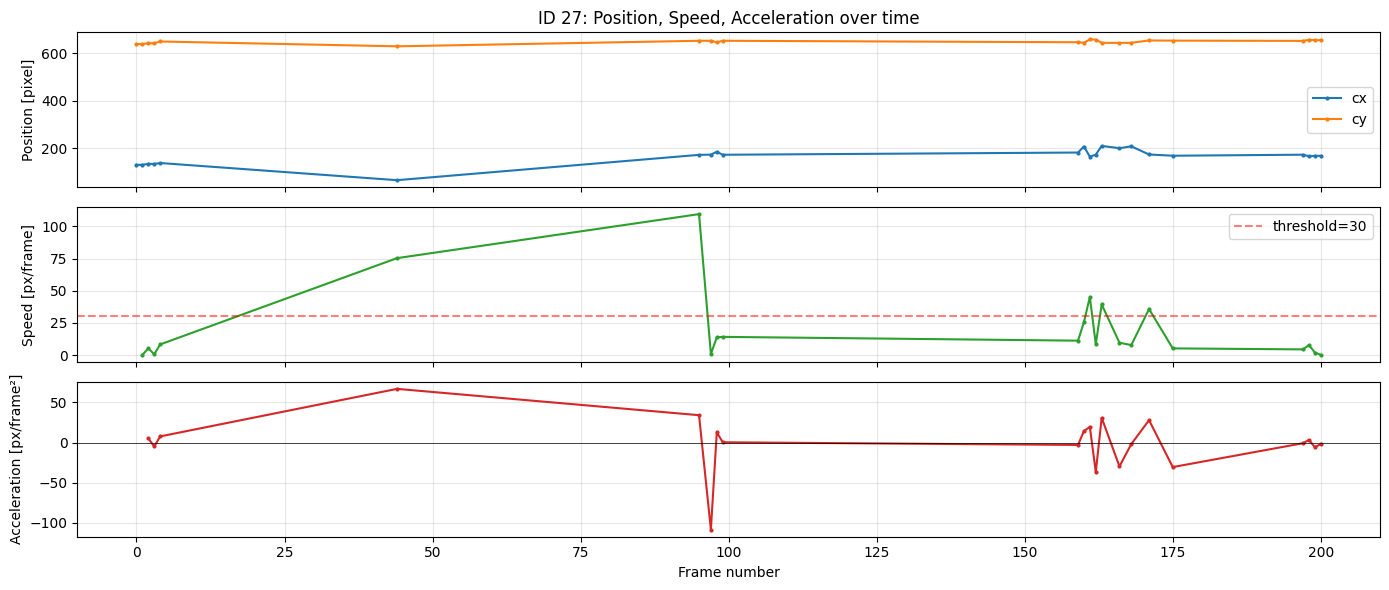

In [29]:
def plot_id_dynamics(df, track_id, figsize=(14, 6)):
    """
    指定IDの軌跡、速度、加速度を時系列で並べて表示する。
    """
    sub = df[df["id"] == track_id].sort_values("frame")
    
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    
    # 上段: x座標の時間変化
    axes[0].plot(sub["frame"], sub["cx"], color="C0", label="cx", marker=".", markersize=4)
    axes[0].plot(sub["frame"], sub["cy"], color="C1", label="cy", marker=".", markersize=4)
    axes[0].set_ylabel("Position [pixel]")
    axes[0].set_title(f"ID {track_id}: Position, Speed, Acceleration over time")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 中段: 速度
    axes[1].plot(sub["frame"], sub["speed"], color="C2", marker=".", markersize=4)
    axes[1].set_ylabel("Speed [px/frame]")
    axes[1].axhline(y=30, color="red", linestyle="--", alpha=0.5, label="threshold=30")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 下段: 加速度
    axes[2].plot(sub["frame"], sub["acceleration"], color="C3", marker=".", markersize=4)
    axes[2].set_ylabel("Acceleration [px/frame²]")
    axes[2].set_xlabel("Frame number")
    axes[2].axhline(y=0, color="black", linewidth=0.5)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 異常値TOPの ID 27 を分析
plot_id_dynamics(df, 27)

**ID 27 の時系列（異常な追跡）**:

- **位置（上段）**: cx は 30〜200、cy は 600〜650 の狭い範囲。画面左下隅にずっといる
- **速度（中段）**: frame 0〜95 にかけて 0 から 109 px/frame まで線形に上昇し、frame 95 で急降下
- **加速度（下段）**: frame 95 で約 -108 の大暴落

**この異常な変化の原因**:

実際には ID 27 は 200 フレームの間に 23 フレームしか検出されていない。matplotlib が「検出されたフレーム同士を直線で結ぶ」ため、長期間検出されていなかった区間が「徐々に加速」したように見えてしまう。

つまり、グラフ上の速度の上昇は **選手が実際に加速したわけではなく、可視化の都合上そう見えているだけ**。実態は「断続的にしか検出できていない」ということ。

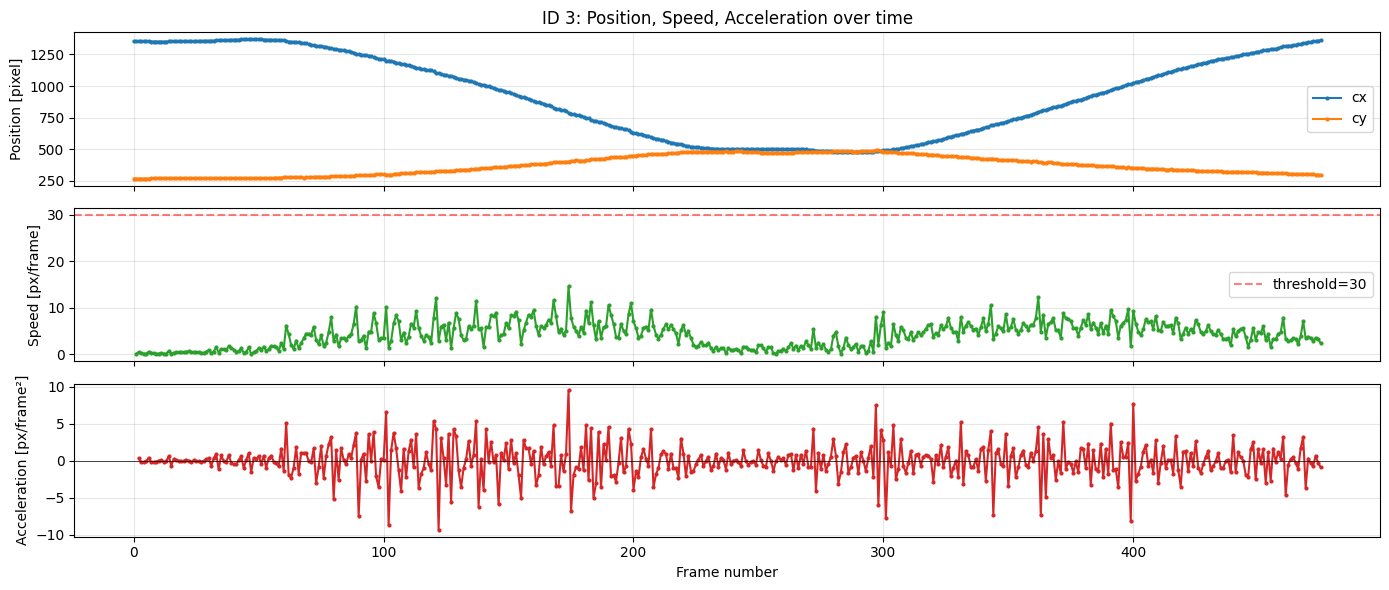

In [30]:
# 完全追跡された ID 3 を分析（コントラスト用）
plot_id_dynamics(df, 3)

**ID 3 の時系列（正常な追跡）**:

- **位置（上段）**: cx は 500〜1350 の範囲で滑らかに変化（右→中央→右に戻るU字型）。cy も 250〜500 で山型の動き
- **速度（中段）**: ほぼ常に 5〜15 px/frame の範囲。最大でも 15 程度で、しきい値 30 を一度も超えない
- **加速度（下段）**: 大半が -5 〜 +5 の範囲。スパイクなし

これは「普通に走っている選手の動き」として自然な変化。ID 27 と比べると、Deep-EIoU が安定して追跡できているIDの動きが明確にわかる。

### 4.6 課題2のまとめ

#### 追加した特徴量

- **速度** (`speed`): フレーム間の中心座標差の大きさ
- **加速度** (`acceleration`): 速度の変化量

#### 計算方法

```python
df["vx"] = df.groupby("id")["cx"].diff()
df["vy"] = df.groupby("id")["cy"].diff()
df["speed"] = (df["vx"]**2 + df["vy"]**2) ** 0.5
df["acceleration"] = df.groupby("id")["speed"].diff()
```

#### 特徴量から分かったこと

**速度の分布**:
- 中央値: 約 2.2 px/frame
- 75%: 約 4.85 px/frame
- 最大値: 約 109 px/frame（明らかな外れ値）

ほとんどの検出は自然な動きの分布に収まっているが、しきい値 30 px/frame を超える異常値が **78件** 存在する。

**異常値の発生場所の傾向**:
- 画面左下端（x < 250, y > 600）で多発
- 同じIDで連続的に異常値が出るケースもある（ID 98, 88 など）

**異常値の原因の考察**:

異常な速度の多くは、**選手が実際に動いた結果ではなく、検出の不安定さが原因**だと考えられる。

具体的には、ID 27 のような短期追跡されたIDでは、

- 検出が断続的（200フレーム中23フレームのみ）
- 検出されたフレーム間を線で結ぶと「長期間の見失い → 一気に位置が変わる」が「徐々に加速した動き」のように見えてしまう

完全追跡された ID 3 と比較すると、安定した追跡では速度が一貫して低く、加速度のスパイクもないことがわかる。

#### 課題2全体での発見

速度と加速度を計算することで、軌跡を見ただけでは分かりにくかった **「追跡の不安定さ」を数値として捉えられる** ようになった。

特に、IDスイッチや断続的な検出は、速度の異常値として明確に現れる。これは課題1で見つけた「IDスイッチの自動検出」を補完する形で、Deep-EIoU の追跡の問題箇所を別の角度から特定できる手段になっている。